# TMNIST Character Classification

In this notebook, I train a simple ANN model to classify 28×28 character images.
The goal is to predict digits, letters, and symbols from the TMNIST dataset.


In [5]:
!kaggle datasets list -s tmnist

ref                                                   title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nimishmagre/tmnist-typeface-mnist                     TMNIST (Typeface MNIST)                      8459994  2021-08-26 14:42:56.833000           2378         54  0.7058824        
nikbearbrown/tmnist-alphabet-94-characters            TMNIST Alphabet (94 characters)             88850214  2021-11-19 21:17:06.993000           2303        159  0.5882353        
nimishmagre/tmnist-glyphs-1812-characters             TMNIST-Glyphs (MNIST Style Glyph images)   158224631  2021-09-21 02:40:05.360000            526         21  0.5882353        
frankhaverland/percentile-tmnist-for-electric-meters  Percentile  TMNIST for electric meters        

## Downloading the Dataset

First, I download the TMNIST dataset from Kaggle directly inside Colab.
This is faster than uploading the large CSV file manually.


In [6]:
!mkdir -p /content/data

!kaggle datasets download \
  -d nikbearbrown/tmnist-alphabet-94-characters \
  -p /content/data \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/nikbearbrown/tmnist-alphabet-94-characters
License(s): Attribution 3.0 Unported (CC BY 3.0)
100% 84.7M/84.7M [00:05<00:00, 16.2MB/s]



## Checking the Downloaded Files

Here I check that the CSV file was downloaded and extracted correctly.


In [7]:
!ls -lh /content/data

total 898M
-rw-r--r-- 1 root root 898M May  7 16:57 94_character_TMNIST.csv


## Loading a Small Sample

Before loading the full dataset, I read only 5 rows.
This helps me quickly check the columns and the data format.


In [8]:
import pandas as pd

CSV_PATH = "/content/data/94_character_TMNIST.csv"

df_sample = pd.read_csv(CSV_PATH, nrows=5)

print(df_sample.shape)
df_sample.head()

(5, 786)


,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Inspecting Columns and Labels

The dataset has font names, target labels, and 784 pixel columns.
I check a few labels and font names to understand the data better.


In [9]:
print("First 10 columns:")
print(df_sample.columns[:10].tolist())

print("\nLast 5 columns:")
print(df_sample.columns[-5:].tolist())

print("\nLabels:")
print(df_sample["labels"].tolist())

print("\nFont names:")
print(df_sample["names"].tolist())

First 10 columns:
['names', 'labels', '1', '2', '3', '4', '5', '6', '7', '8']

Last 5 columns:
['780', '781', '782', '783', '784']

Labels:
['6', 'D', 'f', '/', 'F']

Font names:
['Salsa-Regular', 'MouseMemoirs-Regular', 'Creepster-Regular', 'SeoulNamsan-Light', 'HachiMaruPop-Regular']


## Loading the Full Dataset

Now I load the full CSV file.
This dataset is large, so this step may take a little time.


In [10]:
import pandas as pd

CSV_PATH = "/content/data/94_character_TMNIST.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (274093, 786)


## Basic Dataset Information

Here I check the number of rows, columns, and classes.
This confirms that the dataset is ready for preprocessing.


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Columns:")
print(df.columns[:10].tolist(), "...", df.columns[-5:].tolist())

print("Number of classes:", df["labels"].nunique())
print("First 20 labels:")
print(df["labels"].unique()[:20])

Number of rows: 274093
Number of columns: 786
Columns:
['names', 'labels', '1', '2', '3', '4', '5', '6', '7', '8'] ... ['780', '781', '782', '783', '784']
Number of classes: 94
First 20 labels:
['6' 'D' 'f' '/' 'F' 'x' 'J' '8' 'H' 'k' '@' '1' '=' 'g' ')' '2' 'd' '^'
 '3' 't']


## Viewing One Image

The 784 pixel values represent a 28×28 grayscale image.
I reshape one row and display it to make sure the image looks correct.


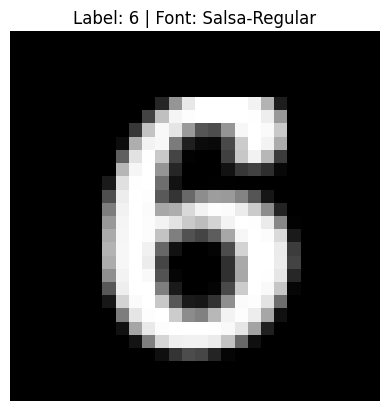

In [12]:
import matplotlib.pyplot as plt
import numpy as np

sample = df.iloc[0]

label = sample["labels"]
font_name = sample["names"]

pixels = sample.drop(["names", "labels"]).values.astype("float32")
image = pixels.reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {label} | Font: {font_name}")
plt.axis("off")
plt.show()

## Dataset Exploration

I check missing values and label counts.
This helps me see if the dataset is balanced or has any obvious problems.


In [13]:
print("Dataset shape:", df.shape)

print("\nNumber of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nNumber of unique labels/classes:", df["labels"].nunique())

print("\nFirst 20 unique labels:")
print(df["labels"].unique()[:20])

print("\nMissing values count:")
print(df.isna().sum().sum())

print("\nTop 10 labels by count:")
print(df["labels"].value_counts().head(10))

print("\nBottom 10 labels by count:")
print(df["labels"].value_counts().tail(10))

Dataset shape: (274093, 786)

Number of samples: 274093
Number of columns: 786

Number of unique labels/classes: 94

First 20 unique labels:
['6' 'D' 'f' '/' 'F' 'x' 'J' '8' 'H' 'k' '@' '1' '=' 'g' ')' '2' 'd' '^'
 '3' 't']

Missing values count:
0

Top 10 labels by count:
labels
6    2990
8    2990
1    2990
4    2990
3    2990
2    2990
0    2990
7    2990
5    2990
9    2990
Name: count, dtype: int64

Bottom 10 labels by count:
labels
C    2874
q    2874
v    2874
z    2874
O    2874
R    2874
L    2874
Z    2874
Q    2874
`    2848
Name: count, dtype: int64


## Splitting Features and Labels

`X` contains only the pixel values.
`y` contains the real character labels that the model should learn to predict.


In [14]:
X = df.drop(["names", "labels"], axis=1).values.astype("float32")
y = df["labels"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("First label:", y[0])
print("First image pixels min:", X[0].min())
print("First image pixels max:", X[0].max())

X shape: (274093, 784)
y shape: (274093,)
First label: 6
First image pixels min: 0.0
First image pixels max: 255.0


## Normalizing Pixel Values

The pixels are originally between 0 and 255.
I divide by 255 so the model trains on values between 0 and 1.


In [15]:
X = X / 255.0

print("After normalization:")
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())
print("Data type:", X.dtype)

After normalization:
Min pixel value: 0.0
Max pixel value: 1.0
Data type: float32


## Encoding the Labels

The model cannot train directly on text labels like `A` or `@`.
So I convert each label into a number using LabelEncoder.


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Number of classes:", len(encoder.classes_))
print("Classes:")
print(encoder.classes_)

print("\nFirst 10 original labels:")
print(y[:10])

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Number of classes: 94
Classes:
['!' '"' '#' '$' '%' '&' "'" '(' ')' '*' '+' ',' '-' '.' '/' '0' '1' '2'
 '3' '4' '5' '6' '7' '8' '9' ':' ';' '<' '=' '>' '?' '@' 'A' 'B' 'C' 'D'
 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V'
 'W' 'X' 'Y' 'Z' '[' '\\' ']' '^' '_' '`' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h'
 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z'
 '{' '|' '}' '~']

First 10 original labels:
['6' 'D' 'f' '/' 'F' 'x' 'J' '8' 'H' 'k']

First 10 encoded labels:
[21 35 69 14 37 87 41 23 39 74]


## Train, Validation, and Test Split

I split the data into training, validation, and testing sets.
The validation set helps monitor training, and the test set is used at the end.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (191865, 784)
y_train: (191865,)
X_val: (41114, 784)
y_val: (41114,)
X_test: (41114, 784)
y_test: (41114,)


## Building the ANN Model

I use a simple fully connected neural network.
The input is 784 pixels and the output has 94 neurons, one for each class.


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(encoder.classes_)

model = models.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 94)             │        24,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,406 (2.13 MB)

 Trainable params: 557,406 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

Now I train the model using the training data.
The validation data is checked after each epoch to see if the model is improving.


In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7457 - loss: 0.9616 - val_accuracy: 0.8518 - val_loss: 0.4969
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8393 - loss: 0.5355 - val_accuracy: 0.8683 - val_loss: 0.4226
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8558 - loss: 0.4634 - val_accuracy: 0.8768 - val_loss: 0.3856
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8650 - loss: 0.4235 - val_accuracy: 0.8819 - val_loss: 0.3637
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8711 - loss: 0.3952 - val_accuracy: 0.8865 - val_loss: 0.3476
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8775 - loss: 0.3718 - val_accuracy: 0.8905 - val_loss: 0.3316
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8817 - loss: 0.3553 - val_accuracy: 0.8913 - val_loss: 0.3260
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8863 - loss: 0.3395 - val_accuracy: 0.

## Plotting Training Curves

These plots show accuracy and loss during training.
They help me detect overfitting or underfitting.


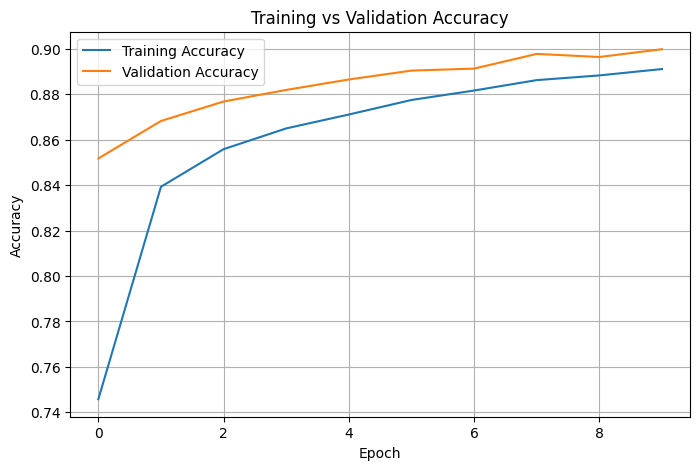

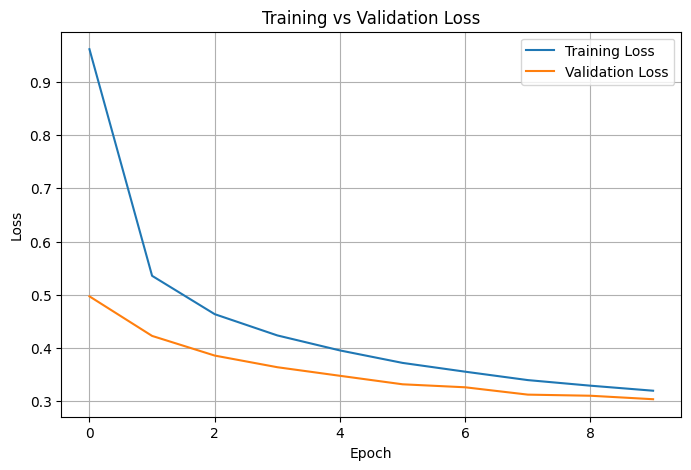

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Evaluating on the Test Set

The test set is used only after training.
This gives a fair score on data the model did not train on.


In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9001 - loss: 0.3065
Test Loss: 0.3065071105957031
Test Accuracy: 0.9000827074050903


## Classification Report

Accuracy alone is not enough.
This report shows precision, recall, and F1-score for every character class.


In [22]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
              precision    recall  f1-score   support

           !       0.96      0.98      0.97       448
           "       0.94      0.97      0.95       447
           #       0.99      0.98      0.98       446
           $       0.96      0.98      0.97       436
           %       0.99      0.97      0.98       445
           &       0.95      0.96      0.95       436
           '       0.86      0.82      0.84       447
           (       0.95      0.96      0.95       447
           )       0.96      0.99      0.97       447
           *       1.00      0.97      0.98       447
           +       0.99      0.99      0.99       447
           ,       0.82      0.94      0.87       448
           -       0.82      0.81      0.81       446
           .       0.94      0.97      0.95       448
           /       0.86      0.96      0.91       447
           0       0.70      0.67      0.68       449
           1       0.87      0.90     

## Full Confusion Matrix

The confusion matrix shows where the model makes mistakes.
Since there are 94 classes, the full matrix is large but still useful.


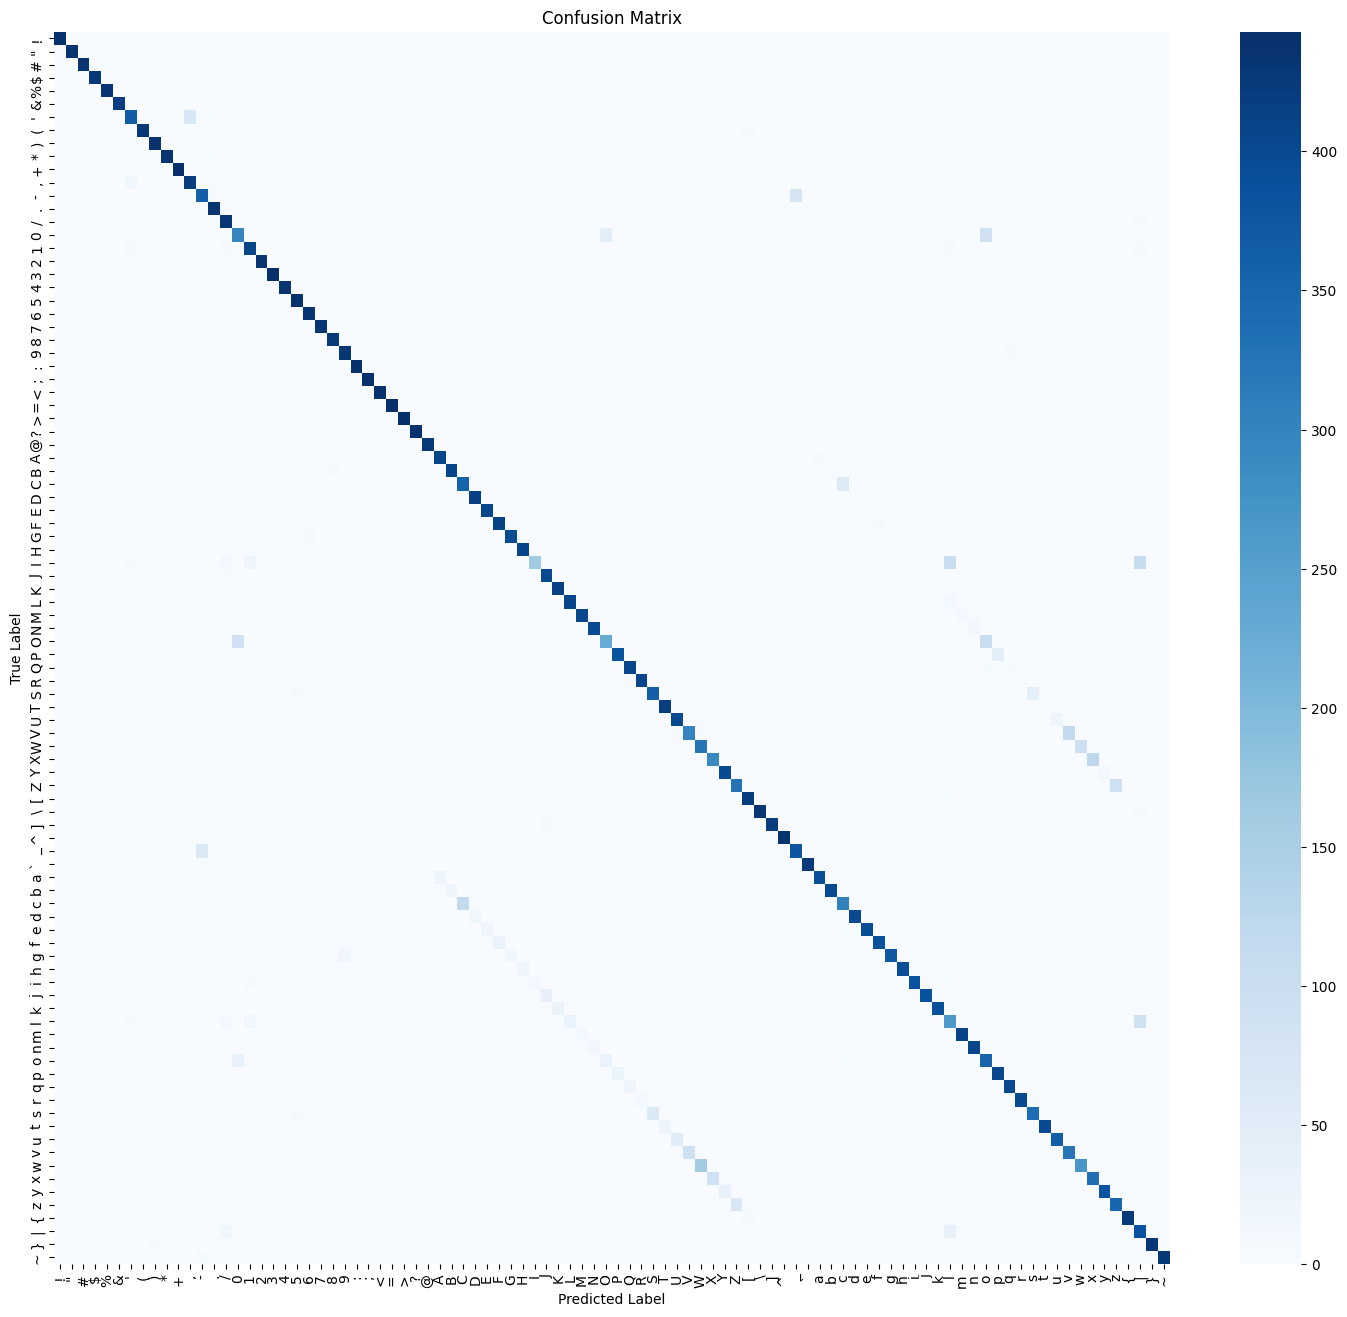

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Top Confusion Errors

The full confusion matrix is hard to read.
So I extract the most common wrong predictions to understand the main mistakes.


In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

top_errors = []

for true_idx in range(cm_errors.shape[0]):
    for pred_idx in range(cm_errors.shape[1]):
        count = cm_errors[true_idx, pred_idx]
        if count > 0:
            top_errors.append({
                "True Label": encoder.classes_[true_idx],
                "Predicted Label": encoder.classes_[pred_idx],
                "Mistakes Count": count
            })

top_errors_df = pd.DataFrame(top_errors)
top_errors_df = top_errors_df.sort_values("Mistakes Count", ascending=False)

top_errors_df.head(20)

,True Label,Predicted Label,Mistakes Count
847,w,W,160
543,X,x,124
524,V,v,116
620,c,C,114
377,I,|,107
450,O,o,105
374,I,l,104
531,W,w,96
564,Z,z,93
838,v,V,93


## Smaller Confusion Matrix

Here I plot only the most confused labels.
This makes the errors easier to see and explain.


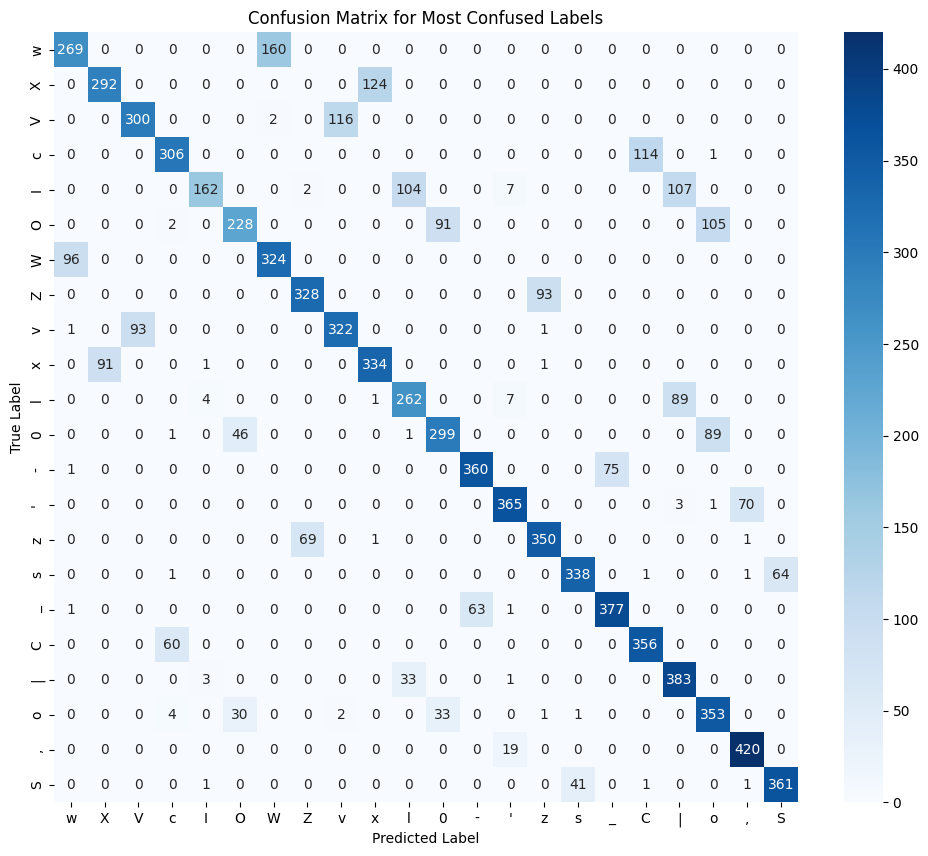

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

top_labels = pd.concat([
    top_errors_df["True Label"].head(20),
    top_errors_df["Predicted Label"].head(20)
]).unique()

top_label_indices = [
    np.where(encoder.classes_ == label)[0][0]
    for label in top_labels
]

cm_small = cm[np.ix_(top_label_indices, top_label_indices)]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_small,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels
)

plt.title("Confusion Matrix for Most Confused Labels")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Saving the Model

I save the trained model and the class labels.
Both files are needed later when using the model in FastAPI.


In [28]:
import os
import numpy as np

SAVE_DIR = "/content/saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, "tmnist_ann_model.keras")
CLASSES_PATH = os.path.join(SAVE_DIR, "label_classes.npy")

model.save(MODEL_PATH)
np.save(CLASSES_PATH, encoder.classes_)

print("Model saved to:", MODEL_PATH)
print("Classes saved to:", CLASSES_PATH)

Model saved to: /content/saved_model/tmnist_ann_model.keras
Classes saved to: /content/saved_model/label_classes.npy


## Testing the Saved Model

I load the saved model again and test it on one sample.
This confirms that the saved files work correctly.


In [29]:
import tensorflow as tf
import numpy as np

loaded_model = tf.keras.models.load_model("/content/saved_model/tmnist_ann_model.keras")
loaded_classes = np.load("/content/saved_model/label_classes.npy", allow_pickle=True)

sample_index = 0

sample_image = X_test[sample_index].reshape(1, 784)
true_label_index = y_test[sample_index]
true_label = loaded_classes[true_label_index]

prediction_probs = loaded_model.predict(sample_image)
predicted_index = np.argmax(prediction_probs)
predicted_label = loaded_classes[predicted_index]
confidence = np.max(prediction_probs)

print("True label:", true_label)
print("Predicted label:", predicted_label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
True label: _
Predicted label: _
Confidence: 0.99725795


## Downloading the Final Files

Finally, I download the saved model and label classes.
These files will be used in the FastAPI deployment.


In [30]:
from google.colab import files

files.download("/content/saved_model/tmnist_ann_model.keras")
files.download("/content/saved_model/label_classes.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>